In [33]:
from ml_enhance import load_hpc_result, compare, CorrelationFilter, FeatureImportance

from sklearn.base import BaseEstimator
from matplotlib.patches import Patch
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np

In [34]:
KRR_combo_filtered_df = load_hpc_result(Path("../data/KRR_results/2_KRR_combo_filtered_results.pkl"), "KRR_topo+QM_filtered", id_as_index=False)
KRR_topo_filtered_df = load_hpc_result(Path("../data/KRR_results/2_KRR_topo_filtered_results.pkl"), "KRR_topo", id_as_index=False)

In [35]:
num_negs_combo = set(KRR_combo_filtered_df.index[KRR_combo_filtered_df["test_r2"] < 0])
num_negs_topo = set(KRR_topo_filtered_df.index[KRR_topo_filtered_df["test_r2"] < 0])

neg_nums = list(num_negs_combo | num_negs_topo)

for fold_id, size in KRR_combo_filtered_df.loc[neg_nums, ["fold_id", "size"]].values:
    print(f"Sample with {fold_id = :.0f} and {size = :.1f} was dropped due to negative 'test_r2'.")

KRR_combo_filtered_df = KRR_combo_filtered_df.drop(neg_nums)
KRR_topo_filtered_df = KRR_topo_filtered_df.drop(neg_nums)

Sample with fold_id = 12 and size = 0.1 was dropped due to negative 'test_r2'.
Sample with fold_id = 16 and size = 0.1 was dropped due to negative 'test_r2'.
Sample with fold_id = 1 and size = 0.1 was dropped due to negative 'test_r2'.


In [36]:
tst1 = KRR_combo_filtered_df.groupby("size")["test_r2"].agg(["mean", "std"])
tst2 = KRR_topo_filtered_df.groupby("size")["test_r2"].agg(["mean", "std"])

tst1 = tst1.rename(columns={"mean": "combo_mean", "std": "combo_std"})
tst2 = tst2.rename(columns={"mean": "topo_mean", "std": "topo_std"})

combined_df = pd.concat([tst1, tst2], axis=1)
combined_df["diff"] = abs(combined_df["combo_mean"] - combined_df["topo_mean"])
combined_df = combined_df.sort_values("diff")
combined_df["num_samples"] = 8763 * combined_df.index
combined_df

,combo_mean,combo_std,topo_mean,topo_std,diff,num_samples
size,,,,,,
0.25,0.822471,0.010408,0.821599,0.010107,0.000872,2190.75
0.50,0.845760,0.010255,0.842313,0.009569,0.003447,4381.50
1.00,0.866426,0.008988,0.861859,0.008829,0.004567,8763.00
0.10,0.789265,0.012541,0.780930,0.015397,0.008335,876.30


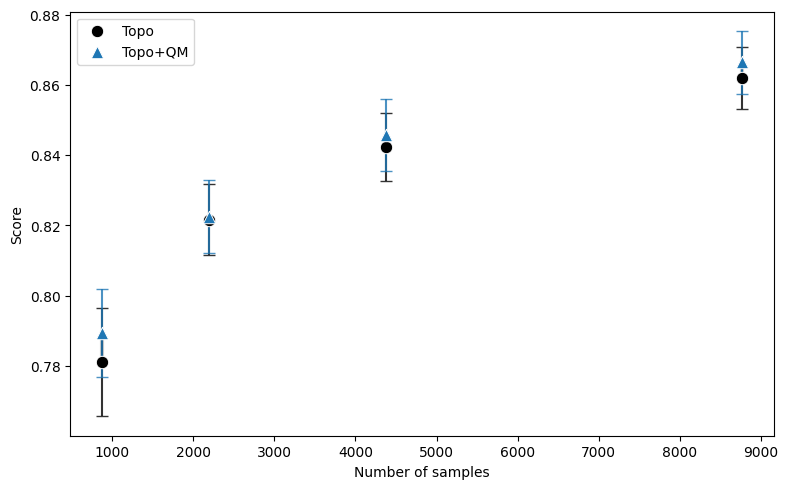

In [26]:
plt.figure(figsize=(8, 5))

# dumbbell lines
for row in combined_df.itertuples():
    plt.plot(
        [row.num_samples, row.num_samples],
        [row.topo_mean, row.combo_mean],
        color="lightgray",
        linewidth=3,
        zorder=1
    )

# scatter points (use seaborn)
sns.scatterplot(
    data=combined_df,
    x="num_samples",
    y="topo_mean",
    color="black",
    s=80,
    label="Topo",
    zorder=3
)

sns.scatterplot(
    data=combined_df,
    x="num_samples",
    y="combo_mean",
    color="tab:blue",
    s=80,
    label="Topo+QM",
    zorder=4,
    marker="^"
)

# error bars
plt.errorbar(
    combined_df["num_samples"],
    combined_df["topo_mean"],
    yerr=combined_df["topo_std"],
    fmt="none",
    ecolor="black",
    capsize=4,
    alpha=0.8,
    zorder=2
)

plt.errorbar(
    combined_df["num_samples"],
    combined_df["combo_mean"],
    yerr=combined_df["combo_std"],
    fmt="none",
    ecolor="tab:blue",
    capsize=4,
    alpha=0.8,
    zorder=2
)

plt.xlabel("Number of samples")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()

In [27]:
from math import ceil, floor

size = 0.1
n_tot = 8763

n_train = floor(floor(n_tot * 0.8) * size)
n_test = ceil(n_tot * 0.2)

print(floor(n_tot * size))
compare(KRR_combo_filtered_df.groupby("size").get_group(size).reset_index(), KRR_topo_filtered_df.groupby("size").get_group(size).reset_index(), n_train=n_train, n_test=n_test)

876
KRR_topo+QM_filtered mean r2: 0.7892647159844411 (Train: 0.9175844762197447)
KRR_topo mean r2: 0.7809295688560621 (Train: 0.9225447823213684)
Mean improvement: 0.008335147128378805
T-test p-value: 0.00176714734068395 -> statistically significant
Wilcoxon p-value: 4.76837158203125e-07 -> statistically significant


KRR_topo+QM_filtered mean MSE: 1.1236392882838049 (Train: 0.4369473133333083)
KRR_topo mean MSE: 1.168187017096819 (Train: 0.4103778693705008)
Mean improvement: -0.0445477288130143
T-test p-value: 0.0018574286652943695 -> statistically significant
Wilcoxon p-value: 4.76837158203125e-07 -> statistically significant




In [28]:

KRR_01_df = KRR_combo_filtered_df[KRR_combo_filtered_df["size"] == size].sort_index()

In [29]:
pos_folds = KRR_01_df[KRR_01_df["test_r2"] > 0].index.to_list()

In [30]:
file = Path(r"..\data\KRR_results\2_KRR_combo_filtered_PFI_results.csv")
krr_combo_fi_df = pd.read_csv(file)
grouped = krr_combo_fi_df[krr_combo_fi_df["fold_id"].isin(pos_folds)].groupby("size")
data = grouped.get_group(size)
groups = data[["fold_id", "feature", "r2_mean"]]
FI_dict = {
    fold_id: df.set_index("feature")["r2_mean"]
    for fold_id, df in groups.groupby("fold_id")
}

In [31]:
FI = FeatureImportance(KRR_01_df[KRR_01_df["test_r2"] > 0], provided_FI=FI_dict)
fi_df = FI.get_feature_importance(20)
FI.plot(20)

ValueError: Missing FI for folds: {32, 64, 96, 36, 68, 40, 72, 76, 92, 48, 80, 52, 84, 56, 88, 60}